# Investment-preference target exploration

The target is a province's percentile rank by development clicks among provinces owned by the same human country in the same save. It measures revealed investment preference, not an intrinsic economic-value formula.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

TARGET_COLUMN = "investment_preference_target"
df = pd.read_csv('./data/provinces_stage3.csv', index_col=0)
required_columns = {TARGET_COLUMN, "target_eligible", "development_clicks", "save", "current_owner"}
missing_columns = required_columns.difference(df.columns)
assert not missing_columns, f"Re-run savefile_extraction.ipynb; missing columns: {sorted(missing_columns)}"

labeled_df = df.loc[df["target_eligible"] & df[TARGET_COLUMN].notna()].copy()

In [13]:
labeled_df[["development_clicks", TARGET_COLUMN]].describe()

,development_clicks,investment_preference_target
count,12194.000000,12194.000000
mean,2.878055,0.505782
std,4.890750,0.245213
min,0.000000,0.013889
25%,0.000000,0.328313
50%,0.000000,0.427083
75%,4.000000,0.721088
max,41.000000,1.000000


In [14]:
coverage_by_player = (
    labeled_df.groupby(["save", "current_owner"], as_index=False)
    .agg(
        labeled_provinces=("province_id", "size"),
        developed_provinces=("development_clicks", lambda values: values.gt(0).sum()),
        maximum_clicks=("development_clicks", "max"),
    )
    .sort_values(["save", "labeled_provinces"], ascending=[True, False])
)
coverage_by_player

,save,current_owner,labeled_provinces,developed_provinces,maximum_clicks
3,mp_Burgundy1500_01_07,MAM,151,40,10
5,mp_Burgundy1500_01_07,PER,87,21,16
6,mp_Burgundy1500_01_07,POL,60,32,15
7,mp_Burgundy1500_01_07,POR,58,5,9
0,mp_Burgundy1500_01_07,BUR,55,21,14
...,...,...,...,...,...
131,mp_Venice1505_01_01,HAB,39,33,18
133,mp_Venice1505_01_01,HSA,35,11,19
139,mp_Venice1505_01_01,SWI,32,12,17
137,mp_Venice1505_01_01,POR,27,8,8


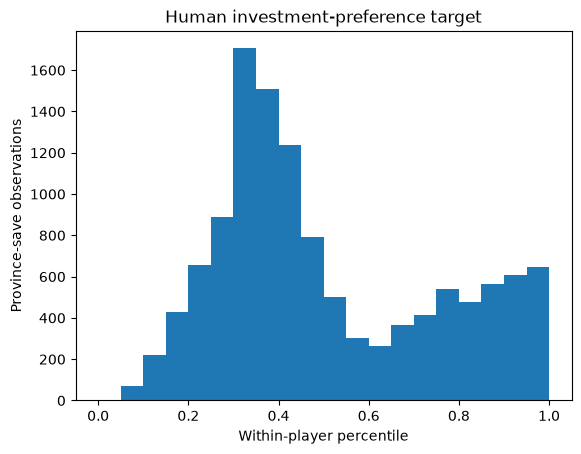

In [15]:
plt.hist(labeled_df[TARGET_COLUMN], bins=20, range=(0, 1))
plt.title("Human investment-preference target")
plt.ylabel("Province-save observations")
plt.xlabel("Within-player percentile")
plt.show()

In [16]:
labeled_df.nlargest(25, [TARGET_COLUMN, "development_clicks"])[
    ["name", "province_id", "save", "current_owner", "development_clicks", TARGET_COLUMN]
]

,name,province_id,save,current_owner,development_clicks,investment_preference_target
24858,Hont,154,mp_Nepal1555_03_27,HUN,41,1.0
30669,Echigo,1024,mp_Nepal1602_08_27,JAP,41,1.0
5792,Mexico,852,mp_France1618_01_01,TEX,33,1.0
29881,London,236,mp_Nepal1602_08_27,GBR,33,1.0
35009,Tblisi,423,mp_Ottomans1642_03_05end,GEO,32,1.0
7920,Lucca,2980,mp_France1618_01_01,FRA,31,1.0
24712,Dalaskogen,8,mp_Nepal1555_03_27,SWE,31,1.0
25150,Herat,446,mp_Nepal1555_03_27,PER,31,1.0
34172,Checiny,4527,mp_Nepal1602_08_27,PLC,30,1.0
41466,Leczyca,1939,mp_Spain1616MP TROLLS,PLC,30,1.0


In [17]:
province_ranking = (
    labeled_df.groupby(["province_id", "name"], as_index=False)
    .agg(
        mean_investment_preference=(TARGET_COLUMN, "mean"),
        median_investment_preference=(TARGET_COLUMN, "median"),
        observations=(TARGET_COLUMN, "size"),
        total_development_clicks=("development_clicks", "sum"),
    )
    .query("observations >= 2")
    .sort_values(["median_investment_preference", "observations"], ascending=[False, False])
)
province_ranking.head(25)

,province_id,name,mean_investment_preference,median_investment_preference,observations,total_development_clicks
2337,4428,Mudgal,0.987179,1.000000,3,64
1260,2058,Mewar,0.787954,0.994083,3,32
1795,2754,LaMancha,0.971426,0.993750,8,119
1092,1816,Beijing,0.800650,0.987641,4,53
2344,4435,Sholapur,0.924896,0.981481,3,29
7,8,Dalaskogen,0.758814,0.980769,8,84
1246,2044,Bhagalpur,0.971111,0.976190,3,42
201,202,Avignon,0.812928,0.974576,5,66
153,154,Hont,0.931188,0.974359,9,155
345,346,Figuig,0.914092,0.972470,8,87


In [18]:
labeled_df.loc[labeled_df["province_id"] == 236, [
    "name", "save", "current_owner", "development_clicks", TARGET_COLUMN
]]

,name,save,current_owner,development_clicks,investment_preference_target
5176,London,mp_France1618_01_01,GBR,4,0.809013
10117,London,mp_Italy1552_04_12,GBR,10,0.920561
15058,London,mp_Lotharingia1519_02_14,ENG,12,0.739130
29881,London,mp_Nepal1602_08_27,GBR,33,1.000000
34822,London,mp_Ottomans1642_03_05end,NED,6,0.615625
39763,London,mp_Spain1616MP TROLLS,GBR,0,0.176136
44704,London,mp_Venice1505_01_01,ENG,10,1.000000


In [19]:
labeled_df

,province_id,new_tax,new_production,new_manpower,changed_owner_num,changed_controller_num,num_buildings,current_owner,development_clicks,is_player_owned,...,middle_x_pos,middle_y_pos,changed_tax,changed_production,changed_manpower,legacy_heuristic_score,has_source_data,target_eligible,investment_preference_target,high_investment_target
0,1,8,14,5,2,5,5,SWE,11,True,...,3077.0,321.0,3,9,2,21,True,True,0.937500,1.0
1,2,4,7,2,2,1,2,SWE,7,True,...,3050.0,349.0,2,5,0,11,True,True,0.800000,1.0
2,3,2,4,1,2,1,2,SWE,2,True,...,3050.0,376.0,0,2,0,6,True,True,0.437500,0.0
3,4,2,8,5,2,7,3,SWE,8,True,...,3045.0,309.0,0,5,3,13,True,True,0.825000,1.0
4,5,2,7,4,2,1,3,SWE,10,True,...,3011.0,318.0,1,6,3,15,True,True,0.900000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49253,4785,2,2,1,2,1,0,ENG,0,True,...,2784.0,453.0,0,0,0,2,True,True,0.385965,0.0
49254,4786,1,4,1,2,5,2,HSA,2,True,...,2991.0,466.0,-1,2,0,5,True,True,0.785714,1.0
49255,4787,2,8,5,2,1,2,POR,5,True,...,2674.0,739.0,-2,5,2,9,True,True,0.907407,1.0
49256,4788,2,2,3,2,1,1,CAS,0,True,...,2711.0,724.0,0,0,2,5,True,True,0.373016,0.0
